In [2]:
from TsmAnalysis.analysis import TsmAnalysis
from TsmAnalysis.input import TrcReader
from TsmAnalysis.plotter import TsmPlotter
from scipy.optimize import curve_fit
from tqdm import tqdm
from matplotlib import cm

import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

path = '../data/time_structure_measurement/20260702'

content = os.listdir(path)
content.sort()
content

/home/maxi/Documents/psi_hipa_tsm/code/Analyses/TsmAnalysis/analysis/TsmAnalysis.py:5: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.optimize import curve_fit


['20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V.json',
 '20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V_DAQInfo.json',
 '20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V.json',
 '20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V_DAQInfo.json',
 '20260702_MXZ1_mxz2@0mm_trglvl_-3.0V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@0mm_trglvl_-3.0V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V_hist.png',
 '20260702_MXZ1_mxz2@0mm_trglvl_-3.0V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@0mm_trglvl_-3.0V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V_hist.png',
 '20260702_MXZ1_mxz2@home_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@home_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V.json',
 '20260702_MXZ1_mxz2@home_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vb

In [3]:
measurement = '20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V'

In [4]:
# Check and create directory for figures
figure_path = os.path.join(path, 'figures')

try:
    os.listdir(figure_path)
except:
    os.makedirs(figure_path)

os.listdir(figure_path)

['20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V.png',
 '20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V.png',
 '20260702_MXZ1_mxz2@home_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V.png']

In [5]:
Trace = TrcReader.TraceReader(path_to_data=os.path.join(path, measurement), chn_pmt=3, chn_rf=1)

pmt, rf, info = Trace.load_traces()
info

Fetching Traces from 20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V.json


{'INSTRUMENT_NAME': 'LECROYWP254HD',
 'INSTRUMENT_NUMBER': 2337,
 'TRACE_LABEL': '',
 'WAVE_ARRAY_COUNT': 402,
 'PNTS_PER_SCREEN': 400,
 'FIRST_VALID_PNT': 0,
 'LAST_VALID_PNT': 401,
 'FIRST_POINT': 0,
 'SPARSING_FACTOR': 1,
 'SEGMENT_INDEX': 0,
 'SUBARRAY_COUNT': 1,
 'SWEEPS_PER_ACQ': 1,
 'POINTS_PER_PAIR': 0,
 'PAIR_OFFSET': 0,
 'VERTICAL_GAIN': 9.124170173890889e-05,
 'VERTICAL_OFFSET': -0.0,
 'MAX_VALUE': 25609.0,
 'MIN_VALUE': -25865.0,
 'NOMINAL_BITS': 12,
 'NOM_SUBARRAY_COUNT': 1,
 'HORIZ_INTERVAL': 5.00000006675716e-11,
 'HORIZ_OFFSET': -1.0031129200258345e-08,
 'PIXEL_OFFSET': -1e-08,
 'VERTUNIT': 'V',
 'HORUNIT': 'S',
 'HORIZ_UNCERTAINTY': 9.999999960041972e-13,
 'TRIGGER_TIME': '2026-07-02T18:51:11.337784',
 'ACQ_DURATION': 0.0,
 'RECORD_TYPE': 'single_sweep',
 'PROCESSING_DONE': 'no_processing',
 'RIS_SWEEPS': 1,
 'TIMEBASE': '2_ns/div',
 'VERT_COUPLING': 'DC_50_Ohms',
 'PROBE_ATT': 1.0,
 'FIXED_VERT_GAIN': '500_mV/div',
 'BANDWIDTH_LIMIT': False,
 'VERTICAL_VERNIER': 1.179

In [6]:
Tsm = TsmAnalysis.TsmAnalysis(pmt, rf)
df = Tsm.df

100%|██████████| 10080/10080 [00:00<00:00, 39534.72it/s]


In [7]:
# Correct trigger timing for ill set oscilloscope system clock (changing the time settings requires administrator rights)

scopetime = dt.datetime(2026, 7, 28, 12, 46)
realtime = dt.datetime(2026, 7, 28, 9, 58)

offset = scopetime - realtime

df.trigger_timing = pmt.trigger_timing

df.trigger_timing -= offset
df.trigger_timing.head()

0   2026-07-02 15:53:04.293706
1   2026-07-02 15:53:04.369629
2   2026-07-02 15:53:04.422420
3   2026-07-02 15:53:04.463726
4   2026-07-02 15:53:04.508896
Name: trigger_timing, dtype: datetime64[us]

In [8]:
# Perform timing calculations by fitting rf reference

Tsm.get_rf_timing(timing='corrected', cfd_bounds=(.2,.8))
df.columns

Estimating corrected pulse arival times


100%|██████████| 10080/10080 [00:06<00:00, 1650.90it/s]


No correcction applied in 0 cases
Calculating pulse timing w.r.t. RF


100%|██████████| 10080/10080 [00:16<00:00, 604.52it/s]


No estimate preduced in 0 instances


Index(['time', 'trigger_timing', 'pmt', 'amp', 'area', 'min_loc',
       'pulse_start', 'ref', 'CFD_corrected_time', 'pulse_delay', 'rise_time',
       'ref_timing', 'ref_init_timing', 'rf_amp', 'rf_freq', 'rf_phase',
       'rf_init_phase', 'rf_bsl_shift', 'reduced_chi2', 'fit_misalignment'],
      dtype='str')

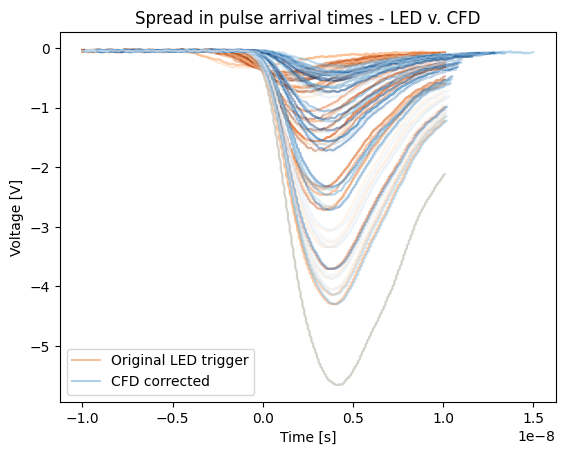

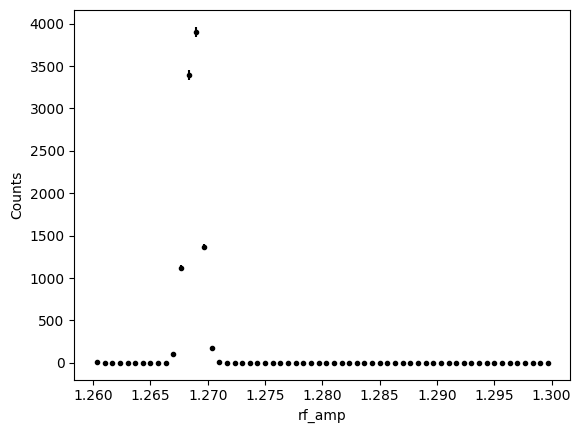

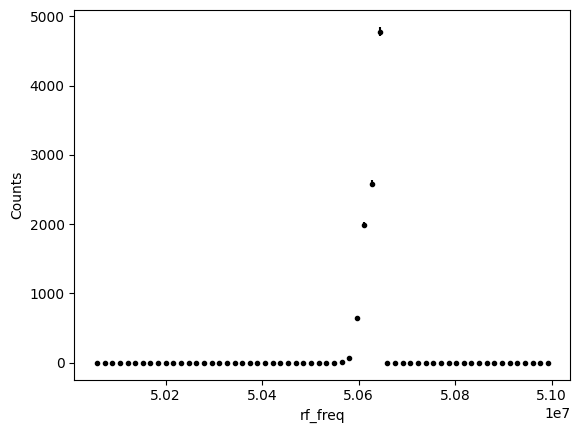

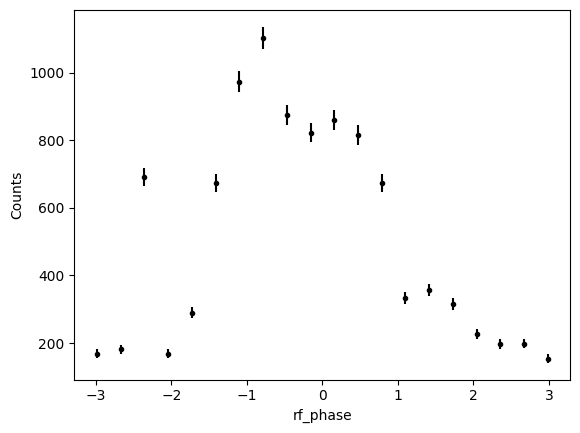

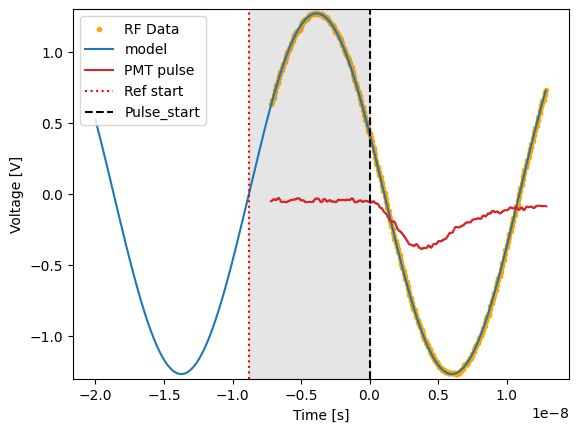

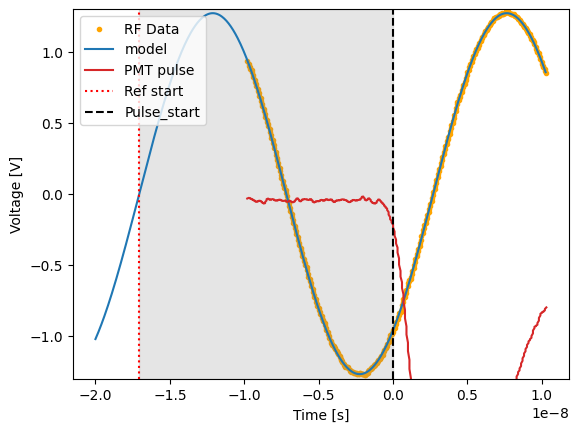

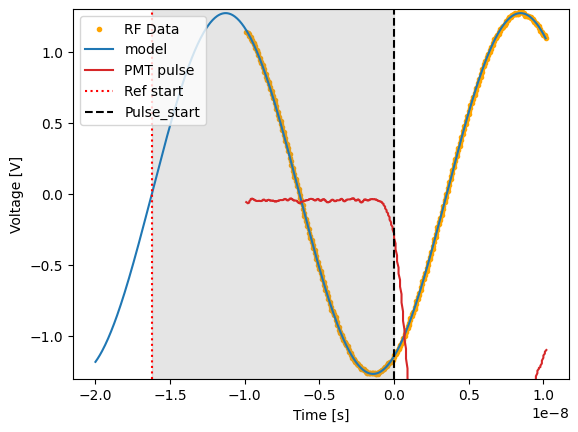

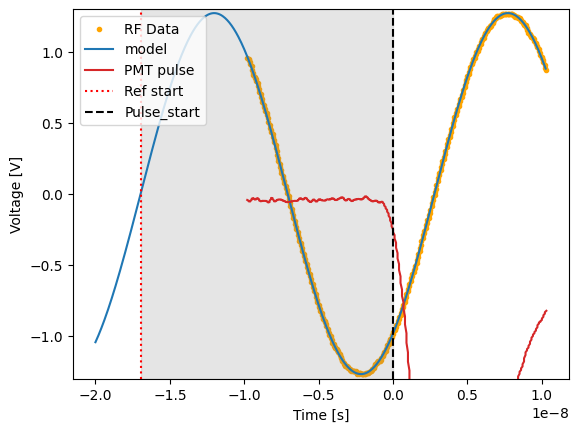

In [9]:
# Check performance of fit

plots = TsmPlotter.TsmPlotter(df)

plots.plot_fit_performance()

In [10]:
df.reduced_chi2.describe

<bound method NDFrame.describe of 0        1.456106e-11
1        1.118816e-11
2        9.617847e-09
3        1.126918e-08
4        5.917875e-08
             ...     
10075    7.064809e-11
10076   -6.526424e-12
10077    2.650789e-13
10078   -6.313447e-11
10079    5.137045e-12
Name: reduced_chi2, Length: 10080, dtype: float64>

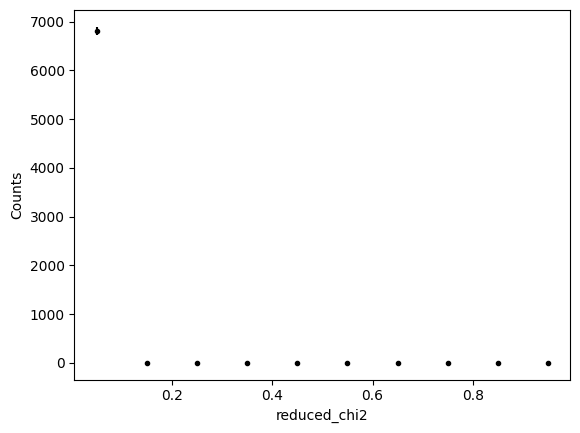

In [11]:
plots.plot_hist('reduced_chi2',nbins=10, range=(0,1))

In [12]:
def phase_to_time(phase, freq):

    period = 1/freq
      
    time = -phase*period/(2*np.pi)

    if time > 0:
        time -= period

    return time
    

df['fit_misalignment'] = df.apply(lambda v: phase_to_time(v.reduced_chi2, v.rf_freq), axis=1)
mask = (df.fit_misalignment > -5e-11) & ~df.isna().any(axis=1)
print(f'acceptance {100*np.round(df[mask].shape[0]/df.shape[0], 2)} %')

print(df.rf_freq[mask].mean())

acceptance 68.0 %
50630881.49966728


In [13]:
rel_fluctuation = df['rf_freq'][mask].std()/df['rf_freq'][mask].mean()*100

print(f'The estimates on the RF frequency have a relative fluctiation of {np.round(rel_fluctuation, 2)} %')
measurement

The estimates on the RF frequency have a relative fluctiation of 0.04 %


'20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V'

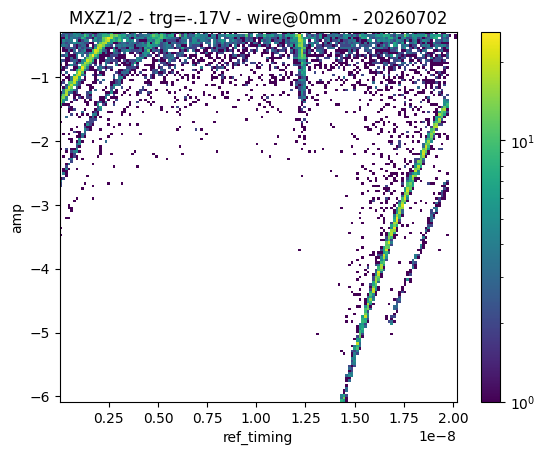

In [14]:
%matplotlib inline

plots = TsmPlotter.TsmPlotter(df)

cut_rf_amp =  mask & (df.rf_amp > 1.285)

# timebase = np.linspace(0, 1/df.rf_freq[mask].mean(), 1002)
# period = 1/df[mask].rf_freq.mean()

# plt.scatter(df[cut_rf_amp].ref_timing, df[cut_rf_amp].amp, marker='o', zorder=0, color='r')

date_str = measurement[:8]
plt.title(r'MXZ1/2 - trg=-.17V - wire@0mm  - '+date_str)
plots.tsm_hist2d(bins=(150,150), save_fig=True, fig_path=figure_path, fn=measurement+".png")


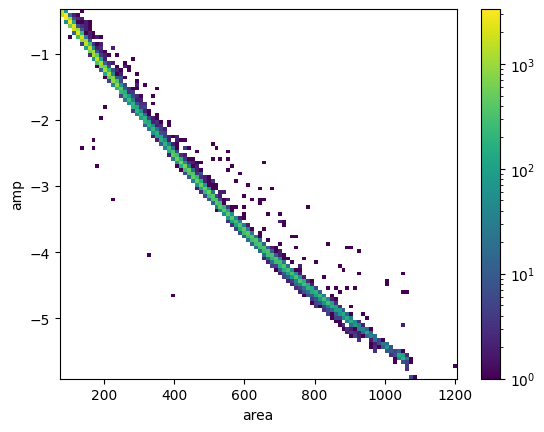

In [95]:
plots.tsm_hist2d(colx='area', coly='amp')

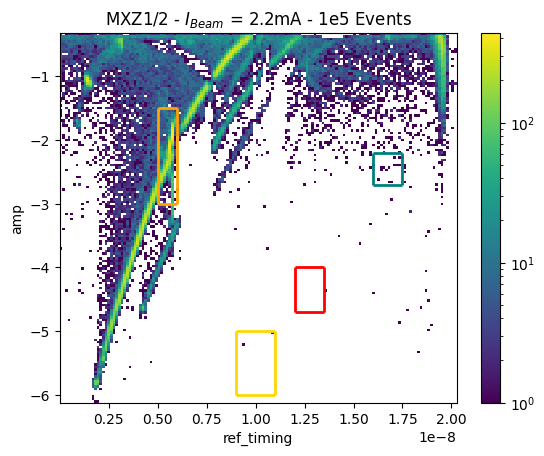

In [35]:
# Create masks to isolate interesting populations for detailed waveform inspection 
%matplotlib inline

plots = TsmPlotter.TsmPlotter(df[mask])

xlim = 0.5e-8, 0.6e-8
ylim = -3, -1.5

mask_lowE = (df.amp > ylim[0]) & (df.amp < ylim[1]) & (df.ref_timing > xlim[0]) & (df.ref_timing < xlim[1]) & mask

plt.title(r'MXZ1/2 - $I_{Beam}$ = 2.2mA - 1e5 Events')
plt.vlines((xlim[0], xlim[1]), ymin=ylim[0], ymax=ylim[1], color='orange', linewidth=2)
plt.hlines((ylim[0], ylim[1]), xmin=xlim[0], xmax=xlim[1], color = 'orange', linewidth=2) 

xlim = 1.2e-8, 1.35e-8
ylim = -4.7, -4

mask_shadow = (df.amp > ylim[0]) & (df.amp < ylim[1]) & (df.ref_timing > xlim[0]) & (df.ref_timing < xlim[1]) & mask


plt.vlines((xlim[0], xlim[1]), ymin=ylim[0], ymax=ylim[1], color='red', linewidth=2)
plt.hlines((ylim[0], ylim[1]), xmin=xlim[0], xmax=xlim[1], color = 'red', linewidth=2) 

xlim =0.9e-8, 1.1e-8
ylim = -6, -5

mask_RoI = (df.amp > ylim[0]) & (df.amp < ylim[1]) & (df.ref_timing > xlim[0]) & (df.ref_timing < xlim[1]) & mask

plt.vlines((xlim[0], xlim[1]), ymin=ylim[0], ymax=ylim[1], color='gold', linewidth=2)
plt.hlines((ylim[0], ylim[1]), xmin=xlim[0], xmax=xlim[1], color = 'gold', linewidth=2) 

xlim = 1.6e-8, 1.75e-8
ylim = -2.7, -2.2 

mask_shitty_pop = (df.amp > ylim[0]) & (df.amp < ylim[1]) & (df.ref_timing > xlim[0]) & (df.ref_timing < xlim[1]) & mask

plt.vlines((xlim[0], xlim[1]), ymin=ylim[0], ymax=ylim[1], color='teal', linewidth=2)
plt.hlines((ylim[0], ylim[1]), xmin=xlim[0], xmax=xlim[1], color = 'teal', linewidth=2) 

plots.tsm_hist2d(bins=(150,150) )


NameError: name 'mask_lowE' is not defined

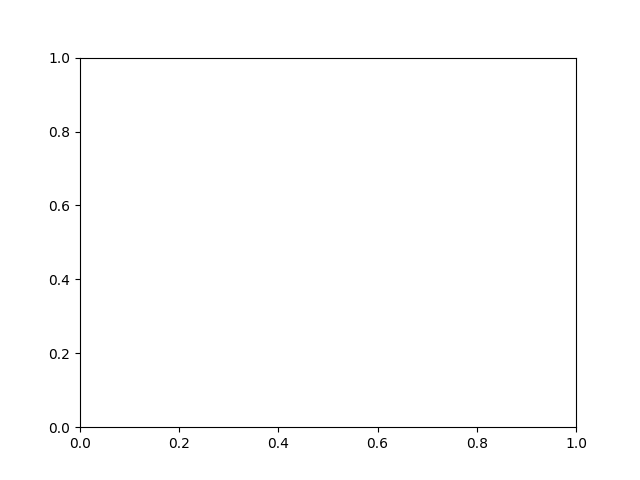

In [1]:
%matplotlib widget

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

i = 0

msk = mask_lowE

x = df.CFD_corrected_time[msk]
y0 = df.pmt[msk]
y1 = df.ref[msk]

rf_time = df.ref_timing[msk]

rf_amp = df.rf_amp[msk]
rf_ang_freq = 2*np.pi*df.rf_freq[msk]
rf_bsl_shift = df.rf_bsl_shift[msk]
rf_phase = df.rf_phase[msk]

fit_miss = df.fit_misalignment[msk]
ylim = -6.1, 1.8

def single_event_viewer(event):

    global i
    
    max_idx = df[msk].shape[0] - 1

    if event.key == 'right' and i < max_idx:
        i += 1
    elif event.key == 'right' and i == max_idx:
        pass
    elif event.key == 'left' and i >= 1: 
        i -= 1
    elif event.key == 'left' and i == 0:
        pass
    elif event.key == 'q':
        plt.close(fig)
        return

    popt =  rf_amp.iloc[i], rf_bsl_shift.iloc[i], rf_ang_freq.iloc[i], rf_phase.iloc[i]
    timebase = np.arange(-2e-8, 1e-8, 5e-10)

    ax.clear()
    ax.plot(x.iloc[i], y0.iloc[i], color='red', label="Index: %i / %i" % (i, max_idx))
    ax.plot(x.iloc[i], y1.iloc[i], color='orange', alpha =.5)
    ax.plot(timebase, Tsm.rf_model(timebase, *popt), color='blue', alpha =.5, label='misalignment: %.2e' % fit_miss.iloc[i])
    ax.axvline(0, color='k', linestyle=':')
    ax.axvline(-rf_time.iloc[i])
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage [V]')
    ax.legend(loc='lower left')
    ax.set_ylim( ylim[0], ylim[1])
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('key_press_event', single_event_viewer)


plt.show()  

In [2]:
period = 1/df.rf_freq.mean()
print(1/period)
phases = []

def sgn(x):
    sign = 0
    if x > 0:
        sign = 1
    elif x < 0:
        sign = -1
    return sign

def slope(x, y, index):
    
    try:
        sign = sgn((y[index + 10] - y[index])/(x[index + 10] - x[index]))
    except:
        sign = sgn((y[index] - y[index - 10])/(x[index] - x[index - 10]))
    return sign




def time_to_phase(time):
    phase = -np.pi*2*time/period
    return phase

for i in range(200):
    time, ref = np.array(df.CFD_corrected_time.iloc[i]), np.array(df.ref.iloc[i])

    neg_half_axis = (time > -6e-9) & (time < 6e-9) 

    time_arr, ref_arr = time[neg_half_axis], ref[neg_half_axis]

    index_zero_xing = np.where(ref_arr**2 == np.min(ref_arr**2))[0][0]

    slope_sign = slope(time_arr, ref_arr, index_zero_xing)
    ref_timing = time_arr[index_zero_xing]

    phase = time_to_phase(ref_timing)

    if slope_sign < 0 and phase < 0:
        phase += np.pi
    elif slope_sign < 0 and phase > 0:
        phase -= np.pi

    phases.append(phase)

    # plt.plot(time_arr, ref_arr, color=f'C{i}')
    # plt.axvline(ref_timing, color=f'C{i}', label=sgn(slope))
# plt.legend()
# plt.axhline(0, color='k')
# # plt.axhline(16e-3, color='red', linestyle=':')
# # plt.ylim(0, 500e-3)
# plt.show()


NameError: name 'df' is not defined

NameError: name 'df' is not defined

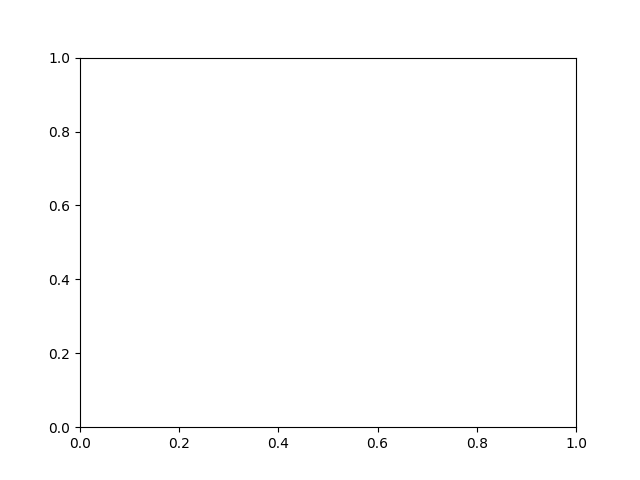

In [3]:
%matplotlib widget

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

i = 0



x = df.CFD_corrected_time
y0 = df.pmt
y1 = df.ref

rf_time = df.ref_timing

rf_amp = df.rf_amp
rf_ang_freq = 2*np.pi*df.rf_freq
rf_bsl_shift = df.rf_bsl_shift
rf_phase = df.rf_phase

fit_miss = df.fit_misalignment
ylim = -6.1, 1.8

def single_event_viewer(event):

    global i
    
    # max_idx = df.shape[0] - 1
    max_idx = 200

    if event.key == 'right' and i < max_idx:
        i += 1
    elif event.key == 'right' and i == max_idx:
        pass
    elif event.key == 'left' and i >= 1: 
        i -= 1
    elif event.key == 'left' and i == 0:
        pass
    elif event.key == 'q':
        plt.close(fig)
        return

    # popt =  rf_amp.iloc[i], rf_bsl_shift.iloc[i], rf_ang_freq.iloc[i], rf_phase.iloc[i]
    timebase = np.arange(-2e-8, 1e-8, 5e-10)

    ax.clear()
    ax.plot(x.iloc[i], y0.iloc[i], color='red', label="Index: %i / %i" % (i, max_idx))
    ax.plot(x.iloc[i], y1.iloc[i], color='orange', alpha =.5)
    # ax.plot(timebase, Tsm.rf_model(timebase, *popt), color='blue', alpha =.5, label='misalignment: %.2e' % fit_miss.iloc[i])
    ax.axvline(0, color='k', linestyle=':')
    ax.axvline(Tsm.phase_to_time(phases[i], df.rf_freq.iloc[i]))
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage [V]')
    ax.legend(loc='lower left')
    ax.set_ylim( ylim[0], ylim[1])
    fig.canvas.draw_idle()
    ax.axhline(0, linestyle='--', color='k')
fig.canvas.mpl_connect('key_press_event', single_event_viewer)


plt.show()  

In [ ]:
poly2 = lambda t, a, b, c: a*t**2 + b*t + c

t1 = 1.5e-8
t2 = 1.58e-8
t3 = 1.68e-8



v1 = -5.5
v2 = -4.5
v3 = -3.5

A = np.array([[t1**2, t1, 1], [t2**2, t2, 1], [t3**2, t3 ,1]])
z = list(np.linalg.solve(A, [v1,v2,v3]))
z

[np.float64(-1.3888888888888395e+17),
 np.float64(5527777777.777619),
 np.float64(-57.1666666666654)]

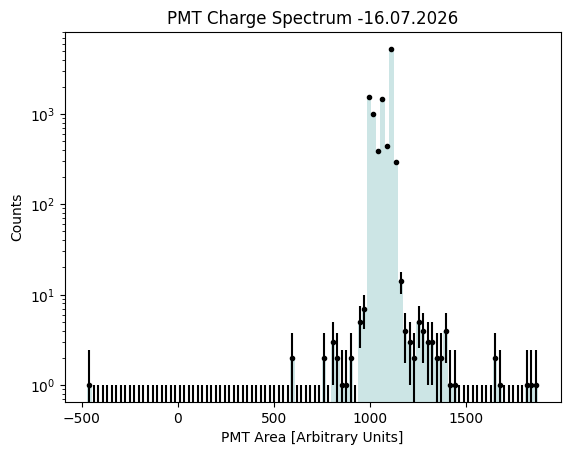

In [23]:
hist, bins = np.histogram(df.area[mask], bins=100)
bin_centers = (bins[1:] + bins[:-1])/2
bin_width = bins[1] - bins[0]

plt.errorbar(bin_centers, hist, yerr=np.sqrt(hist+1), fmt='.', color='k')
plt.bar(bin_centers, hist, bin_width, color='teal', alpha=.2)

plt.title('PMT Charge Spectrum -16.07.2026')
plt.ylabel('Counts')
plt.xlabel('PMT Area [Arbitrary Units]')
plt.yscale('log')
plt.show()


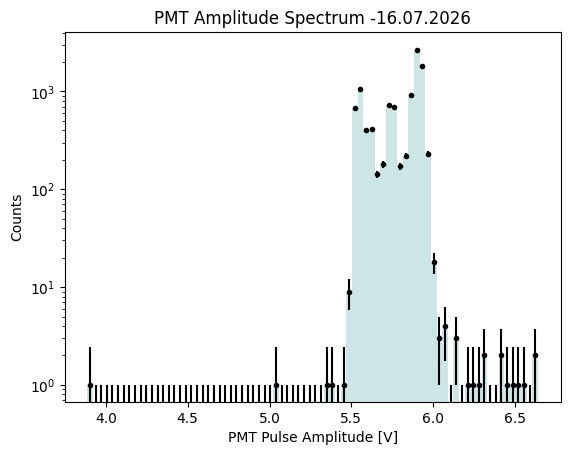

In [24]:
hist, bins = np.histogram(-df.amp[mask], bins=80)
bin_centers = (bins[1:] + bins[:-1])/2

bin_width = bins[1] - bins[0]

plt.errorbar(bin_centers, hist, yerr=np.sqrt(hist+1), fmt='.', color='k')
plt.bar(bin_centers, hist, bin_width, color='teal', alpha=.2)

plt.title('PMT Amplitude Spectrum -16.07.2026')
plt.ylabel('Counts')
plt.xlabel('PMT Pulse Amplitude [V]')
plt.yscale('log')
plt.show()

In [18]:
cmap = plt.cm.viridis
H, xedges, yedges = np.histogram2d(df.ref_timing[mask], df.area[mask], bins=[150, 150], range=((0,1.8e-8), (0,1e3)))
X, Y = np.meshgrid(xedges, yedges)

offset = 0.75

index = int(np.round(np.shape(H)[0]*offset))
H = np.concat((H[:][index:], H[:][:index]), axis=0)
cmap.set_bad(color='white')
        
plt.pcolormesh(X, Y, H.T, norm=cm.colors.LogNorm())
plt.xlabel('Time Difference [s]')
plt.ylabel('Pulse Area [Arbitrary Units]')    
       
plt.colorbar()

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_67480/2462409872.py:16: SyntaxWarning: invalid escape sequence '\s'
  plt.text(x= .95, y=.95, s=f'$\sigma$ = %1.e s' %popt[2], verticalalignment='top', transform=ax.transAxes,
/tmp/ipykernel_67480/2462409872.py:16: SyntaxWarning: invalid escape sequence '\s'
  plt.text(x= .95, y=.95, s=f'$\sigma$ = %1.e s' %popt[2], verticalalignment='top', transform=ax.transAxes,


ValueError: not enough values to unpack (expected 3, got 2)

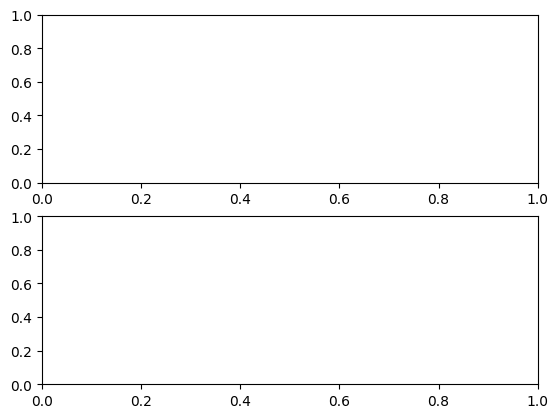

In [ ]:
hist, bins = np.histogram(df.ref_timing[mask_RoI & (df.amp < -5.5)], bins=80)
bin_centers =(bins[1:] + bins[:-1])/2

fig, ax = plt.subplots(2,1)

gauss = lambda t, A, mu, sig: A*np.exp(-((t - mu)/sig)**2/2)

p0 = [sum(hist), 1e-8, 5e-11]

popt, pcov = curve_fit(gauss, bin_centers, hist, p0=p0)
fig, ax = plt.subplots()
# 
ax.set_title('Events in (-4.95 V, -5.05 V)')
ax.errorbar(bin_centers, hist, yerr=np.sqrt(hist), color='k', fmt='.')
plt.plot(bin_centers, gauss(bin_centers, *popt))
plt.text(x= .95, y=.95, s=f'$\sigma$ = %1.e s' %popt[2], verticalalignment='top', transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8))
plt.show()


494 89
nxbins=495.000000 nybins=90.000000


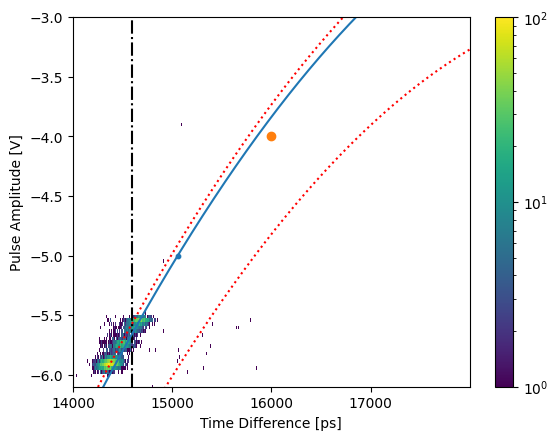

In [ ]:
m, q = (-3.6+6)/(1.7e-8 - 1.5e-8),  -24

f = 3e-3
bounds = [[(1+f)*z[0], (1-f)*z[1], (1+f)*z[2]], [(1-f)*z[0], (1+f)*z[1], (1-f)*z[2]]]

poly_cut_lower = df.amp >= poly2(df.ref_timing, *bounds[0])
poly_cut_upper = df.amp < poly2(df.ref_timing, *bounds[1])

mask2 = mask & poly_cut_lower & poly_cut_upper


popt, pcov = curve_fit(poly2, df.ref_timing[mask2], df.amp[mask2], p0=z, bounds=bounds)

t = np.linspace(1.4e-8, 1.8e-8, 1000)

inv_poly = lambda A: (-popt[1] + np.sqrt(popt[1]**2 - 4*popt[0]*(popt[2]-A)))/2/popt[0]

# plt.axhline(-5.05, linestyle='--', alpha=.4,color='k')
# plt.axhline(-4.95, linestyle='--', alpha=.4,color='k')
plt.axvline(1.46e-8, linestyle='-.', color='k')
# plt.fill_between(np.linspace(1.4e-8, 1.8e-8, 100), -5.05, -4.95, color='grey', alpha=.2)
plt.plot(t, poly2(t, *bounds[0]), color='r', linestyle=':')
plt.plot(t, poly2(t, *bounds[1]), color='r', linestyle=':')
# plt.plot*t, poly2(t, *z, color='k', linestyle=':')
plt.plot(t, poly2(t, *popt))
plt.scatter(inv_poly(-5), -5, zorder=10, s=10)
plt.scatter(1.6e-8, -4)
plots.tsm_hist2d(bins=(100,100), range=([1.4e-8, 1.8e-8], [-6.1, -3.]))

x = np.linspace(1.4e-8, 1.8e-8, 500)


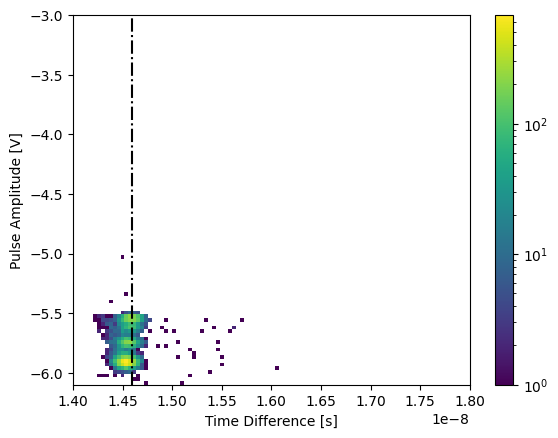

In [ ]:
# Correct for drift in arrival times by transform timing information ref_timing with poly2 fit to data.ChildProcessError

transformation_pole = 1.46e-8

df['ref_timing_transformed'] = df.apply(lambda v: v.ref_timing - (inv_poly(v.amp) - transformation_pole), axis=1)

time_range = ([1.4e-8, 1.8e-8], [-6.1, -3.])

H, xedges, yedges = np.histogram2d(df.ref_timing_transformed[mask], df.amp[mask], bins=[100,100],range=([1.4e-8, 1.8e-8], [-6.1, -3.]))
X, Y = np.meshgrid(xedges, yedges)

cmap = plt.cm.viridis
cmap.set_bad(color='white')

xticks = np.linspace(time_range[0], time_range[1], 6)
tick_labels = np.rint(xticks/1e-12)

H = np.ma.masked_where(H == 0, H)

tr = np.arange(1.5e-8, 1.65e-8, 1e-10)

plt.pcolormesh(X,Y,H.T, norm=cm.colors.LogNorm(), )
plt.colorbar()
plt.axvline(1.46e-8, linestyle='-.', color='k')

# plt.xticks(ticks=xticks, labels=[f"{tick:.0f}" for tick in tick_labels])
plt.xlabel('Time Difference [s]')
plt.ylabel('Pulse Amplitude [V]')
plt.show()        


<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_33167/1968879382.py:17: SyntaxWarning: invalid escape sequence '\s'
  plt.text(x= .95, y=.95, s=f'$\sigma$ = %1.e s' %popt[2], verticalalignment='top', transform=ax.transAxes,


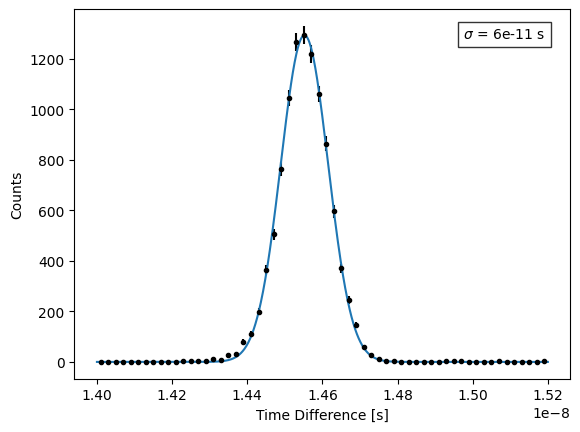

np.float64(2.0000000000001172e-11)

In [ ]:
proj = H.T.sum(axis=0)

hist, bins = np.histogram(df.ref_timing_transformed[mask], bins=60, range=(1.4e-8, 1.52e-8))
bin_centers =(bins[1:] + bins[:-1])/2

p0 = [sum(hist), 1.46e-8, 5e-11]

popt, pcov = curve_fit(gauss, bin_centers, hist, p0=p0)
fig, ax = plt.subplots()

t=np.linspace(1.4e-8, 1.52e-8, 1000)

plt.errorbar(bin_centers, hist, yerr=np.sqrt(hist), color='k', fmt='.')
plt.plot(t, gauss(t, *popt))
plt.xlabel('Time Difference [s]')
plt.ylabel('Counts')
plt.text(x= .95, y=.95, s=f'$\sigma$ = %1.e s' %popt[2], verticalalignment='top', transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8))
plt.show()
bin_centers[1] - bin_centers[0]

In [ ]:
# Back-up code

# Fragments already implemented in TsmAnalysis or replaced by other method

"""
def ref_model(t, A, B, w, phi):
        return A*np.sin(w*t + phi) + B

def ref_fit(time, ref_trace, init_params=None):

      bounds = ([1.2, -1e-2, 3.1e8, -np.inf], [1.4,1e-2, 3.2e8, np.inf])
      popt, pcov = curve_fit(ref_model, time, ref_trace, p0=init_params, bounds=bounds)
      
      return popt, pcov

def phase_to_time(phase, w):
      freq = w/(2*np.pi)
      period = 1/freq
      
      time = phase*period/(2*np.pi)
      
      return time

init_p = [1.2, 0, 2*np.pi*50.6e6, 0]

ref_t = []
best_p = []

for i in tqdm(range(df.shape[0])):
      
      time = np.array(df.time[i])
      ref = np.array(df.ref[i])
      
      slice_fit_time = time[(time<1e8) & (time > -1e8)]
      slice_fit_rf = ref[(time<1e8) & (time > -1e8)]

      try:
            popt, pcov = ref_fit(slice_fit_time, slice_fit_rf, init_params=init_p)
            phase = popt[3]
            ang_freq = popt[2]
      except:
            phase = np.nan
            ang_freq = np.nan
            print('something went wrong in the plot')
      t = phase_to_time(phase, ang_freq) 
      
      if i < 5:
                  
            plt.plot(time, ref, marker='.',alpha=.1)
            plt.plot(time, ref_model(np.array(time), *popt), label='RF')
            plt.axhline(0, color='k', linestyle=':',  label='pulse')
            plt.axvline(-t, color='r', linestyle='--')
            plt.axvline(0, color='k', linestyle=':')
            plt.xlabel('time [s]')
            plt.ylabel('voltage')
            plt.title(fr'$\phi$ = %.02f, $\omega$ = %0.02f' %(phase, ang_freq))
            plt.legend()
            plt.show()
      best_p.append(popt)
      ref_t.append(t)

      loc = 0
peak_position = df.min_loc[loc]

amp_10p = .1*df.amp[loc]
amp_90p = .9*df.amp[loc]

amp = np.array(df.pmt[loc][:peak_position])
time = np.array(df.time[loc][:peak_position])

plt.plot(time, amp)
plt.axhline(amp_10p, color='k', linestyle=':')
plt.axhline(amp_90p, color='k', linestyle=':')

mask = (amp < amp_10p) & (amp > amp_90p)

amp = amp[mask]
time = time[mask]

plt.plot(time, amp)

line = lambda t, m, q: m*t + q

def CFD(df, threshold):
    
    print('Computing corrected pulse arrival times')
    
    corrected_time = []

    for i in tqdm(range(df.shape[0])):

        peak_position = df.min_loc[i]

        amp_10p = .1*df.amp[i]
        amp_90p = .9*df.amp[i]

        full_amp = np.array(df.pmt[i][:peak_position])
        full_time = np.array(df.time[i][:peak_position])

        mask = (full_amp < amp_10p) & (full_amp > amp_90p) 

        amp = full_amp[mask]
        time = full_time[mask]

        p0 = [(amp.min() - amp.max())/(time.max() - time.min()), -.5]
        bounds = ([-np.inf, -np.inf],[0, np.inf])

        popt, pcov, = curve_fit(line, time, amp, p0=p0, bounds=bounds)
    
        pulse_delay_index = np.where(np.abs(line(full_time,*popt)) == np.min(np.abs(line(full_time,*popt))))[0][0]
        pulse_delay = full_time[pulse_delay_index]
        correct = df.time[i] - pulse_delay
        
        corrected_time.append(correct)
    
    df['CFD_corrected_time'] = corrected_time
CFD(df, threshold=1)

# Run once to save traces in pandas DataFrames for quick loading


# tsm_dirs = next(os.walk(path))[1]
# tsm_dirs
# data_dir = os.path.join('path', tsm_dirs[0])

# for data_dir in tqdm(tsm_dirs):
#     print('loading %s to csv' % data_dir)
#     data_path = os.path.join(path, data_dir)
#     print(data_path)
#     Trace = TraceReader(data_path, 3)
#     traces = Trace.traces

#     pmt = Trace.load_traces()
    
#     pmt.voltage = pmt.voltage.apply(lambda v: [float(x) for x in v])
#     pmt.time = pmt.time.apply(lambda v: [float(x) for x in v])

#     Trace = TraceReader(data_path, 1)
#     traces = Trace.traces
    
#     ref = Trace.load_traces()
    
#     ref.voltage = ref.voltage.apply(lambda v: [float(x) for x in v])
#     ref.time = pmt.time.apply(lambda v: [float(x) for x in v])

#     pmt.to_csv(os.path.join(data_path, data_dir+'_pmt_traces.csv'))
#     ref.to_csv(os.path.join(data_path, data_dir+'_rf_traces.csv'))

# Trace = TraceReader(os.path.join(path,'20260615_MXZ1_mxz2@0mm_trglvl_-3.51V_beamI_200uA'), chn=3)

# pmt = Trace.load_traces()
v_thresh = np.linspace(-4, -6, 10)

for v in v_thresh:
    mask = (df.fit_misalignment > -5e-11) & (df.amp < v)
    hist, bins = np.histogram(-df.ref_timing[mask], bins=100, range=(14e-9, 19e-9))
    bin_centers = (bins[:-1] + bins[1:])/2
    bin_width = bins[1]-bins[0]
    plt.errorbar(bin_centers, hist, xerr=bin_width/2, yerr=np.sqrt(hist), fmt='.', color='k')
    for i in range(len(hist)):
        plt.fill_between((bin_centers[i]-bin_width/2, bin_centers[i]+bin_width/2), hist[i], color='blue', alpha=.2 )
    plt.xlabel('Relative Arrival Time [s]')
    plt.ylabel('Counts')
    plt.title('PMT amp < %.02fV' %v)
    plt.savefig(os.path.join(path,measurement+'_hist.png'))
    plt.show()

time_range = (1.4e-8, 1.9e-8)
H, xedges, yedges = np.histogram2d(-df.ref_timing[mask], df.amp[mask], bins=[100,100])
X, Y = np.meshgrid(xedges, yedges)

cmap = plt.cm.viridis
cmap.set_bad(color='white')

# xticks = np.linspace(time_range[0], time_range[1], 6)
# tick_labels = np.rint(xticks/1e-12)

H = np.ma.masked_where(H == 0, H)

plt.pcolormesh(X,Y,H.T, norm=cm.colors.LogNorm(), )
plt.colorbar()
# plt.xticks(ticks=xticks, labels=[f"{tick:.0f}" for tick in tick_labels])
plt.xlabel('Time Difference [ps]')
plt.ylabel('Pulse Amplitude [V]')
plt.show()

fast_pop = ( df.fit_misalignment > -5e-11) & (-df.ref_timing > 1.4e-8) & (-df.ref_timing < 1.6e-8)

line = lambda x, m, q: m*x+q 

# popt, pcov = curve_fit(line, -df_orig.re

popt, pcov = curve_fit(line, -df.ref_timing[fast_pop], df.amp[fast_pop])

time_range = (1.4e-8, 1.9e-8)
H, xedges, yedges = np.histogram2d(-df.ref_timing[mask], df.amp[mask], bins=[100,100])

index = int(np.round(np.shape(H)[0]))

H = np.concat((H[:][index:], H[:][:index]), axis=0)

X, Y = np.meshgrid(xedges, yedges)

cmap = plt.cm.viridis
cmap.set_bad(color='white')

xticks = np.linspace(time_range[0], time_range[1], 6)
tick_labels = np.rint(xticks/1e-12)

H = np.ma.masked_where(H == 0, H)

tr = np.arange(1.5e-8, 1.65e-8, 1e-10)

plt.pcolormesh(X,Y,H.T, norm=cm.colors.LogNorm(), )
plt.plot(tr, line(tr, *popt))
plt.colorbar()
plt.xticks(ticks=xticks, labels=[f"{tick:.0f}" for tick in tick_labels])
plt.xlabel('Time Difference [s]')
plt.ylabel('Pulse Amplitude [V]')
plt.show()        
"""

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_33167/55028485.py:5: SyntaxWarning: invalid escape sequence '\p'
  """


'\ndef ref_model(t, A, B, w, phi):\n        return A*np.sin(w*t + phi) + B\n\ndef ref_fit(time, ref_trace, init_params=None):\n\n      bounds = ([1.2, -1e-2, 3.1e8, -np.inf], [1.4,1e-2, 3.2e8, np.inf])\n      popt, pcov = curve_fit(ref_model, time, ref_trace, p0=init_params, bounds=bounds)\n\n      return popt, pcov\n\ndef phase_to_time(phase, w):\n      freq = w/(2*np.pi)\n      period = 1/freq\n\n      time = phase*period/(2*np.pi)\n\n      return time\n\ninit_p = [1.2, 0, 2*np.pi*50.6e6, 0]\n\nref_t = []\nbest_p = []\n\nfor i in tqdm(range(df.shape[0])):\n\n      time = np.array(df.time[i])\n      ref = np.array(df.ref[i])\n\n      slice_fit_time = time[(time<1e8) & (time > -1e8)]\n      slice_fit_rf = ref[(time<1e8) & (time > -1e8)]\n\n      try:\n            popt, pcov = ref_fit(slice_fit_time, slice_fit_rf, init_params=init_p)\n            phase = popt[3]\n            ang_freq = popt[2]\n      except:\n            phase = np.nan\n            ang_freq = np.nan\n            print(\